# Algorithm overview

Compares all seven matching algorithms across the full (d, R) sweep for one
geometry, from summary data. Plots: key metrics vs R and vs d, the service rate
vs safety scatter, algorithm x R heatmaps, declines per driver, and a
behaviour/ic interaction check.

Run once per geometry. Cross geometry deltas are in `geometry_effect.ipynb`.

`d` is the average distance between taxis, so larger d means fewer taxis and
less supply.


In [1]:
from pathlib import Path

# Switch geometry and re-run all cells to compare layouts.
GEOMETRY = 'balanced'          # 'balanced' or 'imbalanced'

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False        # True ignores the pickle cache and re-parses .gz

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import load_experiment_set, fmt_display, exp_label, apply_pub_style, legend_outside

apply_pub_style()

## 1. Load all experiments for the chosen geometry

One row per run. `load_experiment_set` adds `experiment`, `algorithm`, and
`geometry` columns so every plot can label by algorithm directly.

In [ ]:
df = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, force=FORCE_RECOMPUTE)
if df.empty:
    raise RuntimeError(
        f'No data for geometry={GEOMETRY!r}. Run  python notebooks/cache_all.py  first.'
    )

EXPERIMENTS = sorted(df['experiment'].unique())
EXP_ALGO = df.drop_duplicates('experiment').set_index('experiment')['algorithm'].to_dict()
EXP_LABEL = {e: exp_label(e, EXP_ALGO[e]) for e in EXPERIMENTS}
_cmap = plt.get_cmap('tab10')
EXP_COLOR = {e: _cmap(i % 10) for i, e in enumerate(EXPERIMENTS)}

R_vals = sorted(df['R'].dropna().unique())
d_vals = sorted(df['d'].dropna().unique())

print(f'Geometry   : {GEOMETRY}')
print(f'R values   : {R_vals}')
print(f'Fleet sizes: {[int(v) for v in d_vals]}  (larger d = fewer taxis)')
print(f'Runs/exp   : {df.groupby("experiment").size().to_dict()}')
for e in EXPERIMENTS:
    print(f'  {EXP_LABEL[e]}')

In [4]:
KEY_METRICS = [
    ('service_rate',            'Service rate',             '{:.3f}'),
    ('final_safety_mean',       'Mean driver safety',       '{:.2f}'),
    ('final_satisfaction_mean', 'Mean satisfaction',        '{:.2f}'),
    ('income_gini',             'Income Gini',              '{:.3f}'),
    ('wait_to_pickup_mean',     'Mean wait to pickup (TU)', '{:.1f}'),
]
KEY_METRICS = [(c, l, f) for c, l, f in KEY_METRICS if c in df.columns]

# Overview table: mean of each metric per algorithm, averaged over d/R/behaviour/ic.
ov = df.groupby('experiment')[[c for c, _, _ in KEY_METRICS]].mean().reindex(EXPERIMENTS)
ov.insert(0, 'algorithm', [EXP_ALGO[e] for e in ov.index])
display(fmt_display(ov.reset_index(), fmt={c: f for c, _, f in KEY_METRICS}))

,experiment,algorithm,service_rate,final_safety_mean,final_satisfaction_mean,income_gini,wait_to_pickup_mean
0,exp1,nearest,0.592,67.51,86.60,0.090,29.9
1,exp2,nearest_region_pref,0.592,67.46,86.36,0.096,29.9
2,exp3,nearest_distance_pref,0.594,67.47,94.47,0.106,29.9
3,exp4,nearest_passenger_pref,0.589,67.51,86.07,0.104,29.4
4,exp5,nearest_two_sided_region_pass_pref,0.585,67.70,85.64,0.098,29.3
5,exp6,safety_objective_two_sided,0.581,67.52,84.98,0.120,28.8
6,exp7,safety_objective,0.584,67.09,85.56,0.127,29.1


## 2. Key metrics vs demand ratio R

One line per algorithm in a 2x3 grid. Each point averages over behaviour and
initial conditions. Error bars show the standard deviation across fleet sizes d
at that R.


In [ ]:
n = len(KEY_METRICS)
ncols = 3
nrows = int(np.ceil((n + 1) / ncols))   # +1 slot reserves room for a shared legend
fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).reshape(-1)
handles = labels = None
for ax, (col, label, _f) in zip(axes, KEY_METRICS):
    for e in EXPERIMENTS:
        sub = df[df['experiment'] == e]
        per_d = sub.groupby(['R', 'd'])[col].mean().reset_index()   # collapse beh/ic
        gmean = per_d.groupby('R')[col].mean().reindex(R_vals)
        gstd = per_d.groupby('R')[col].std().reindex(R_vals)
        ax.errorbar(R_vals, gmean.values, yerr=gstd.values, fmt='o-',
                    color=EXP_COLOR[e], label=EXP_LABEL[e],
                    capsize=3, linewidth=1.8, markersize=5)
    ax.set_xlabel('Demand ratio R')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(R_vals)
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
for ax in axes[n:]:
    ax.axis('off')
if handles:
    axes[n].legend(handles, labels, loc='center', fontsize=12,
                   title='Algorithm', frameon=False)
plt.tight_layout()
plt.show()

## 3. Key metrics vs fleet size d

Small multiples: one panel per algorithm, one line per R. Reveals how each
algorithm scales with supply. Remember larger d = fewer taxis.

In [ ]:
ncols = 4
nrows = int(np.ceil(len(EXPERIMENTS) / ncols))
r_cmap = plt.get_cmap('plasma')
RCOLOR = {r: r_cmap(i / max(len(R_vals) - 1, 1)) for i, r in enumerate(R_vals)}

for col, label, _f in KEY_METRICS:
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.0 * nrows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, e in zip(axes, EXPERIMENTS):
        sub = df[df['experiment'] == e]
        for r in R_vals:
            g = sub[sub['R'] == r].groupby('d')[col].mean()
            ax.plot(g.index, g.values, 'o-', color=RCOLOR[r],
                    label=f'R={r}', markersize=3, linewidth=1.4)
        ax.set_title(EXP_LABEL[e], fontsize=12)
        ax.set_xlabel('Fleet size d')
    for ax in axes[len(EXPERIMENTS):]:
        ax.axis('off')
    fig.suptitle(f'{label} vs fleet size d - {GEOMETRY}', y=1.0)
    fig.tight_layout()
    legend_outside(fig, ax=axes[0], title='R')
    plt.show()

## 4. Service rate vs driver safety

The central thesis plot. Each point is one (algorithm, d, R) combination,
averaged over behaviour/ic. Colour = algorithm, marker size grows with R.
Algorithms toward the upper right deliver both high service and high safety.


In [ ]:
agg = (df.groupby(['experiment', 'd', 'R'])[['service_rate', 'final_safety_mean']]
         .mean().reset_index())
fig, ax = plt.subplots(figsize=(8.5, 6.5))
for e in EXPERIMENTS:
    s = agg[agg['experiment'] == e]
    ax.scatter(s['service_rate'], s['final_safety_mean'],
               s=25 + s['R'] * 130, color=EXP_COLOR[e], label=EXP_LABEL[e],
               alpha=0.7, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Service rate')
ax.set_ylabel('Mean driver safety')
ax.set_title(f'Service-safety trade-off - {GEOMETRY}\n'
             f'point = (algorithm, d, R); marker size ~ R')
fig.tight_layout()
legend_outside(fig, ax=ax)
plt.show()

### 4b. Mean driver safety vs R

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))

per_exp_r = agg.groupby(['experiment', 'R'])['final_safety_mean'].mean()
overall   = agg.groupby('R')['final_safety_mean'].mean().reindex(R_vals)

for e in EXPERIMENTS:
    vals = per_exp_r.loc[e].reindex(R_vals)
    ax.plot(R_vals, vals.values, 'o-', color=EXP_COLOR[e],
            label=EXP_LABEL[e], linewidth=1.4, markersize=4, alpha=0.7)

ax.plot(R_vals, overall.values, 'o-', color='black', linewidth=2.5,
        markersize=7, label='cross-algo mean', zorder=5)

ax.set_xlabel('Demand ratio R')
ax.set_ylabel('Mean driver safety score')
ax.set_title(f'Mean driver safety vs R - {GEOMETRY}\n'
             f'(averaged over d, behaviour, initial conditions)')
ax.set_xticks(R_vals)
fig.tight_layout()
legend_outside(fig, ax=ax)
plt.show()

## 5. Algorithm x R heatmaps

Ranking of algorithms at a glance. Each point averages over d, behaviour, and
initial conditions.

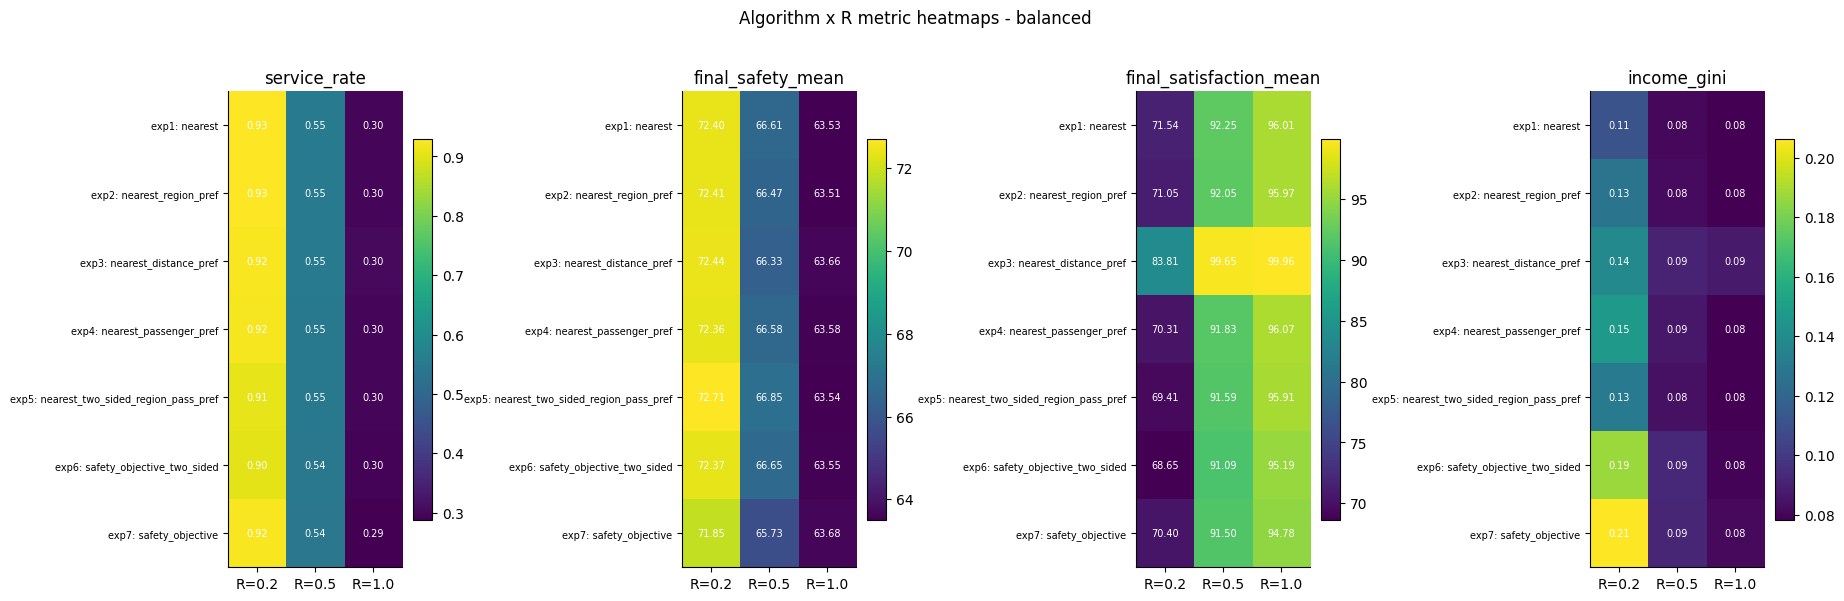

In [9]:
metrics_hm = [m for m in ['service_rate', 'final_safety_mean',
                          'final_satisfaction_mean', 'income_gini']
              if m in df.columns]
fig, axes = plt.subplots(1, len(metrics_hm),
                         figsize=(4.6 * len(metrics_hm), 0.55 * len(EXPERIMENTS) + 2))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, metrics_hm):
    piv = df.pivot_table(index='experiment', columns='R', values=col,
                         aggfunc='mean').reindex(EXPERIMENTS)
    im = ax.imshow(piv.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'R={c}' for c in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([EXP_LABEL[e] for e in piv.index], fontsize=12)
    ax.set_title(col)
    ax.grid(False)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=12, color='white')
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f'Algorithm x R metric heatmaps - {GEOMETRY}', y=1.02)
plt.tight_layout()
plt.show()

## 6. Declines per driver

Average declines per driver by algorithm and R. Only the preference and safety
objective algorithms (Exp 2-6) generate declines. The nearest baseline (Exp 1)
and the centralized safety objective (Exp 7) should sit near zero.


In [ ]:
if 'avg_total_declines' in df.columns:
    piv = df.pivot_table(index='experiment', columns='R', values='avg_total_declines',
                         aggfunc='mean').reindex(EXPERIMENTS)
    decl_exps = [e for e in EXPERIMENTS if piv.loc[e].fillna(0).sum() > 0]
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(R_vals))
    w = 0.8 / max(len(decl_exps), 1)
    for i, e in enumerate(decl_exps):
        ax.bar(x + i * w, piv.loc[e].reindex(R_vals).values, w,
               color=EXP_COLOR[e], label=EXP_LABEL[e])
    ax.set_xticks(x + w * (len(decl_exps) - 1) / 2)
    ax.set_xticklabels([f'R={r}' for r in R_vals])
    ax.set_ylabel('driver declines per driver')
    ax.set_title(f'Driver declines per driver by R and algorithm - {GEOMETRY}\n'
                 f'(only the decline-generating algorithms shown)')
    legend_outside(fig, ax=ax, title='Algorithm')
    plt.tight_layout()
    plt.show()
else:
    print('avg_total_declines not available in summary data')

## 7. Behaviour and initial condition interaction check

Sections 2-6 average over the four `behaviour x initial_conditions` combinations
(`stay`/`go_back` crossed with `base`/`home`), which is only sound if the
combination matters little relative to the algorithm differences. The cells
below check this. The verdict table compares the largest gap between combos at
a fixed (algorithm, R) with the largest gap between algorithms at a fixed R,
and a small ratio means the averaging is safe. The spread plot shows the worst
case per algorithm against that range, and the marginal plot shows the raw
`stay` vs `go_back` and `base` vs `home` differences directly.


In [11]:
beh_cols = [c for c in ['behaviour', 'initial_conditions'] if c in df.columns]
HAVE_BEH = bool(beh_cols) and not all(df[c].nunique() <= 1 for c in beh_cols)

if not HAVE_BEH:
    print('Only one behaviour/initial_conditions combination present - nothing to check.')
else:
    df['beh_combo'] = df[beh_cols].astype(str).agg('/'.join, axis=1)
    combos = sorted(df['beh_combo'].unique())
    print(f'behaviour x ic combinations: {combos}')

    # spread = how far apart the combos sit at a fixed (algorithm, R) after averaging
    #   over d -- this is exactly what collapsing in Sections 2-6 throws away.
    # range  = how far apart the algorithms sit at a fixed R after the collapse --
    #   this is the signal the notebook is built to show.
    rows = []
    for col, label, _f in KEY_METRICS:
        per_combo = df.groupby(['experiment', 'R', 'beh_combo'])[col].mean().reset_index()
        spread = per_combo.groupby(['experiment', 'R'])[col].agg(lambda s: s.max() - s.min())
        collapsed = df.groupby(['experiment', 'R'])[col].mean()
        algo_range = collapsed.groupby('R').agg(lambda s: s.max() - s.min())
        max_spread = float(spread.max())
        max_range = float(algo_range.max())
        rows.append({
            'metric': label,
            'max behaviour spread': max_spread,
            'max cross-algo range': max_range,
            'spread / range': (max_spread / max_range) if max_range else np.nan,
        })
    verdict = pd.DataFrame(rows)
    display(fmt_display(verdict, fmt={
        'max behaviour spread': '{:.3f}',
        'max cross-algo range': '{:.3f}',
        'spread / range': '{:.2f}',
    }))
    print('spread / range << 1  =>  behaviour/ic effect is small next to the algorithm')
    print('effect, so the Sections 2-6 averaging is safe for that metric. A ratio near')
    print('or above 1 means behaviour/ic could flip a ranking -- add a behaviour facet.')


behaviour x ic combinations: ['go_back/base', 'go_back/home', 'stay/base', 'stay/home']


,metric,max behaviour spread,max cross-algo range,spread / range
0,Service rate,0.041,0.026,1.56
1,Mean driver safety,0.806,1.123,0.72
2,Mean satisfaction,3.903,15.161,0.26
3,Income Gini,0.074,0.095,0.78
4,Mean wait to pickup (TU),4.049,3.651,1.11


spread / range << 1  =>  behaviour/ic effect is small next to the algorithm
effect, so the Sections 2-6 averaging is safe for that metric. A ratio near
or above 1 means behaviour/ic could flip a ranking -- add a behaviour facet.


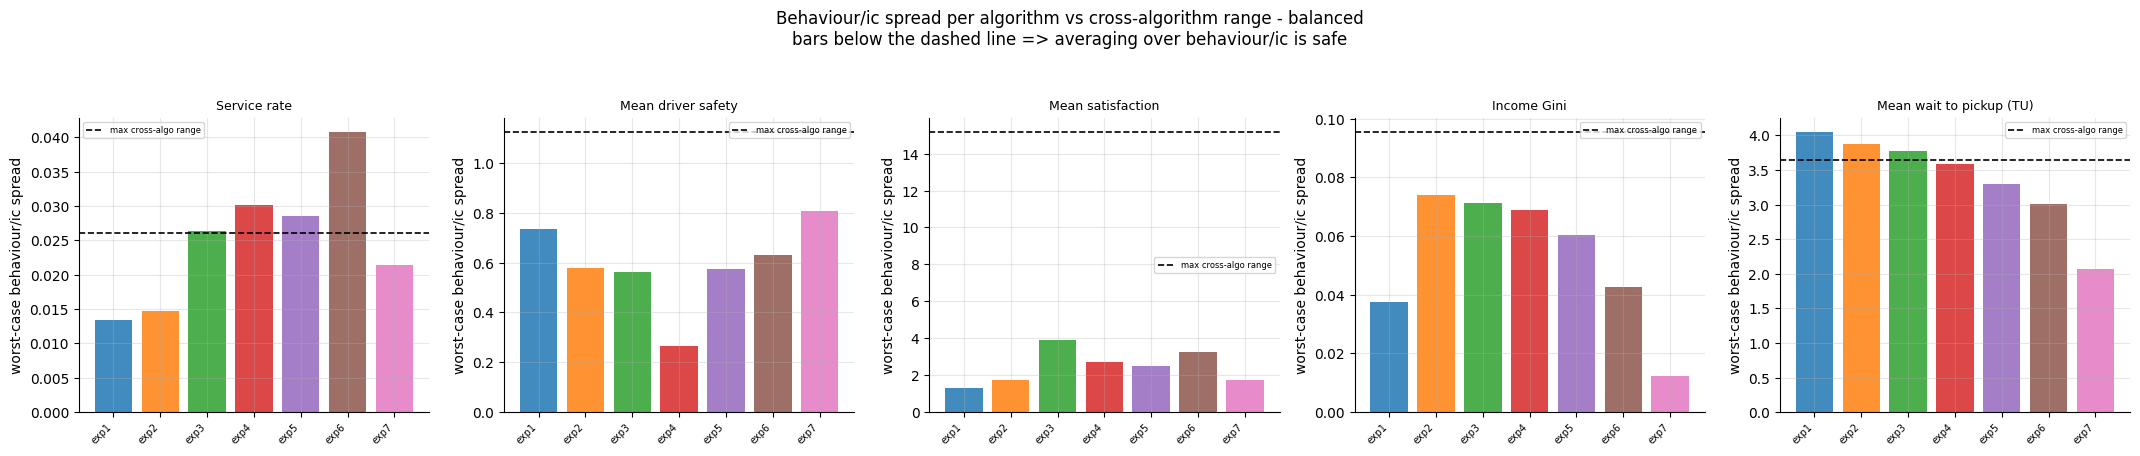

In [12]:
if HAVE_BEH:
    fig, axes = plt.subplots(1, len(KEY_METRICS), figsize=(4.3 * len(KEY_METRICS), 4.3))
    axes = np.atleast_1d(axes)
    for ax, (col, label, _f) in zip(axes, KEY_METRICS):
        per_combo = df.groupby(['experiment', 'R', 'beh_combo'])[col].mean().reset_index()
        spread = per_combo.groupby(['experiment', 'R'])[col].agg(lambda s: s.max() - s.min())
        per_exp = spread.groupby('experiment').max().reindex(EXPERIMENTS)
        collapsed = df.groupby(['experiment', 'R'])[col].mean()
        max_range = float(collapsed.groupby('R').agg(lambda s: s.max() - s.min()).max())

        x = np.arange(len(EXPERIMENTS))
        ax.bar(x, per_exp.values, color=[EXP_COLOR[e] for e in EXPERIMENTS], alpha=0.85)
        ax.axhline(max_range, color='black', linestyle='--', linewidth=1.2,
                   label='max cross-algo range')
        ax.set_xticks(x)
        ax.set_xticklabels(EXPERIMENTS, rotation=45, ha='right', fontsize=12)
        ax.set_ylabel('worst-case behaviour/ic spread')
        ax.set_title(label, fontsize=12)
        ax.legend(fontsize=12, loc='best')
    fig.suptitle(f'Behaviour/ic spread per algorithm vs cross-algorithm range - {GEOMETRY}\n'
                 'bars below the dashed line => averaging over behaviour/ic is safe', y=1.05)
    plt.tight_layout()
    plt.show()


In [ ]:
if HAVE_BEH:
    combos = sorted(df['beh_combo'].unique())
    _ccmap = plt.get_cmap('tab10')
    CCOLOR = {c: _ccmap(i % 10) for i, c in enumerate(combos)}

    fig, axes = plt.subplots(1, len(KEY_METRICS), figsize=(4.3 * len(KEY_METRICS), 4.3))
    axes = np.atleast_1d(axes)
    for ax, (col, label, _f) in zip(axes, KEY_METRICS):
        for c in combos:
            sub = df[df['beh_combo'] == c]
            g = sub.groupby('R')[col].mean().reindex(R_vals)
            ax.plot(R_vals, g.values, 'o-', color=CCOLOR[c], label=c,
                    linewidth=1.5, markersize=4)
        ax.set_xlabel('Demand ratio R')
        ax.set_title(label, fontsize=12)
        ax.set_xticks(R_vals)
    fig.suptitle(f'Marginal behaviour/ic effect (averaged over algorithm and d) - {GEOMETRY}',
                 y=1.03)
    fig.tight_layout()
    legend_outside(fig, ax=axes[0], title='behaviour/ic')
    plt.show()


## Significance

Two tests per comparison (see `guides/STATISTICAL_ANALYSIS_PLAN.md`):

- **Sweep**: paired Wilcoxon signed rank across the x1 sweep, points paired by
  d / R / behaviour / ic. The headline test. `sweep_cliff` is Cliff's delta,
  `sweep_signs` the sign agreement count, `sweep_p_adj` the Holm corrected p.
- **Focus**: replicate test at the focus point (d=258, R=0.5, go_back, ic=home,
  K=11 runs per algorithm). `foc_diff` with its 95% CI is the Welch mean
  difference. `foc_cohens_d` and `foc_cliff` are the effect sizes.
  `foc_welch_p` and `foc_mw_p` are the Welch and Mann-Whitney p values.

Positive deltas mean the first algorithm scores higher. P values are Holm
corrected within each metric. Gini is never t-tested, its focus p value comes
from Mann-Whitney and the headline inequality claim uses a bootstrap CI.
Trajectories are compared in `safety_evolution.ipynb` because successive
batches are autocorrelated.


In [14]:
from exp_utils import significance_summary, FOCUS_SETUP

# Sweep uses the x1 sweep (df, reps excluded); focus uses the replicate frame.
df_reps = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, include_reps=True,
                              force=FORCE_RECOMPUTE)

SIG_METRICS = [m for m in ['service_rate', 'final_safety_mean', 'final_satisfaction_mean',
                           'wait_to_pickup_mean', 'income_gini'] if m in df.columns]
COMPARISONS = [(e, 'exp1') for e in EXPERIMENTS if e != 'exp1']

sig = significance_summary(df, df_reps, COMPARISONS, SIG_METRICS, setup=FOCUS_SETUP)
SIG_SHOW = ['comparison', 'metric', 'sweep_n', 'sweep_p_adj', 'sweep_cliff', 'sweep_mag',
            'sweep_signs', 'foc_diff', 'foc_ci_lo', 'foc_ci_hi', 'foc_welch_p',
            'foc_mw_p', 'foc_p_adj', 'foc_cohens_d']
SIG_FMT = {'sweep_p_adj': '{:.2g}', 'sweep_cliff': '{:+.2f}', 'foc_diff': '{:+.3f}',
           'foc_ci_lo': '{:+.3f}', 'foc_ci_hi': '{:+.3f}', 'foc_welch_p': '{:.2g}',
           'foc_mw_p': '{:.2g}', 'foc_p_adj': '{:.2g}', 'foc_cohens_d': '{:+.2f}'}
SIG_SHOW = [c for c in SIG_SHOW if c in sig.columns]
display(fmt_display(sig[SIG_SHOW], fmt=SIG_FMT))

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,metric,sweep_n,sweep_p_adj,sweep_cliff,sweep_mag,sweep_signs,foc_diff,foc_ci_lo,foc_ci_hi,foc_welch_p,foc_mw_p,foc_p_adj,foc_cohens_d
0,exp2 vs exp1,service_rate,60,0.13,+0.07,negligible,39/60 a>b,+0.002,+0.001,+0.004,0.011,0.01,0.032,+1.21
1,exp2 vs exp1,final_safety_mean,60,1,-0.02,negligible,31/60 a<b,-0.054,-0.333,+0.226,0.69,0.79,1,-0.17
2,exp2 vs exp1,final_satisfaction_mean,60,0.0024,-0.07,negligible,39/60 a<b,+0.089,-0.127,+0.305,0.4,0.51,0.8,+0.37
3,exp2 vs exp1,wait_to_pickup_mean,60,0.58,-0.02,negligible,30/60 a<b,-0.005,-0.243,+0.234,0.97,0.79,0.97,-0.02
4,exp2 vs exp1,income_gini,60,5.1e-05,+0.09,negligible,45/60 a>b,-0.000,-0.002,+0.001,-,1,1,-
5,exp3 vs exp1,service_rate,60,0.016,+0.16,small,43/60 a>b,+0.008,+0.006,+0.010,1.1e-08,8.2e-05,6.6e-08,+4.20
6,exp3 vs exp1,final_safety_mean,60,1,-0.04,negligible,33/60 a<b,-0.202,-0.444,+0.040,0.097,0.17,0.29,-0.74
7,exp3 vs exp1,final_satisfaction_mean,60,9.8e-11,+0.56,large,60/60 a>b,+7.527,+7.392,+7.663,3.4e-18,8.2e-05,2e-17,+52.19
8,exp3 vs exp1,wait_to_pickup_mean,60,0.58,+0.02,negligible,37/60 a>b,+0.079,-0.119,+0.277,0.41,0.32,0.82,+0.36
9,exp3 vs exp1,income_gini,60,9.8e-11,+0.51,large,60/60 a>b,+0.008,+0.007,+0.010,-,8.2e-05,0.00049,-
